### Testing for Independent Variable Stationarity

In [406]:
features = X_train

In [407]:
#Testing independent vars for stationarity

results = []

for var in features:
    adf_test = adfuller(bike_sales_data[var])
    results.append({
    'col': [var],
    'p-value': adf_test[1],
    'stationary': adf_test[1] < 0.05})

adf_results = pd.DataFrame(results)

#They seem stationary, but plots don't agree below

In [408]:
adf_results

,col,p-value,stationary
0,[branded_search_spend],0.004192,True
1,[nonbranded_search_spend],0.158104,False
2,[facebook_spend],0.002240,True
3,[print_spend],0.019252,True
4,[ooh_spend],0.098887,False
5,[tv_spend],0.257574,False
6,[radio_spend],0.041335,True


/var/folders/5k/0mrs71sj38b3m6trnqsfqlx00000gp/T/ipykernel_10088/441782470.py:19: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=3.0)


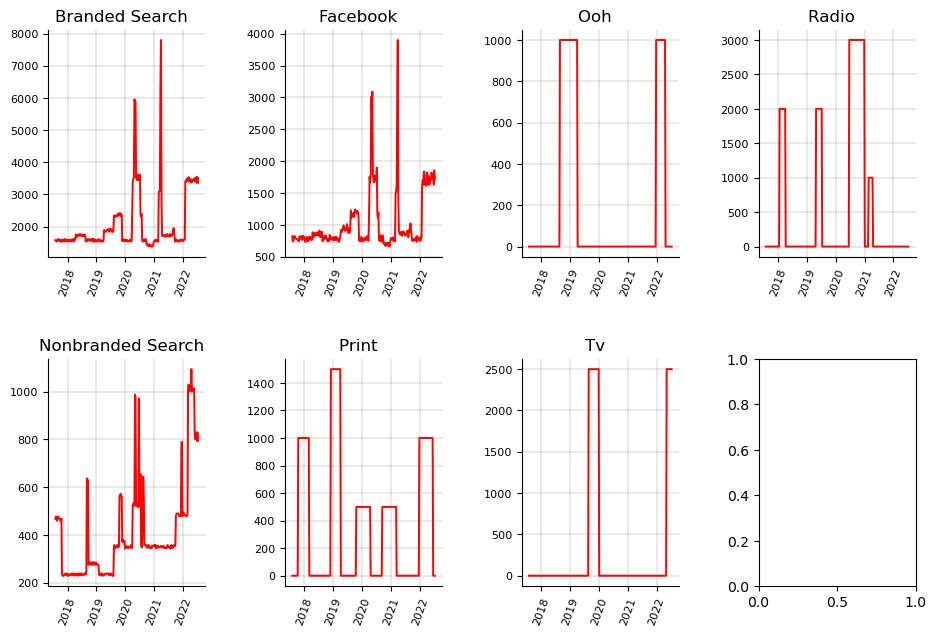

In [409]:


ncols = 2
nrows = len(bike_sales_data_stationary.columns) - 1 // ncols

fig, axs = plt.subplots(2, 4, constrained_layout=True, figsize=(10,7))
for col, ax in zip(bike_sales_data_stationary.drop('sales', axis=1).columns, axs.T.ravel()):
    #bike_sales_data[[col]].boxplot(ax=ax)
    ax.plot(bike_sales_data_stationary.index, bike_sales_data_stationary[[col]], label = "interest_rate", linestyle = 'solid', linewidth = '1.4', c='r')
    ax.xaxis.set_tick_params(rotation=70, labelsize=8)
    ax.yaxis.set_tick_params(labelsize=8)
    ax.set_title(str(col).title().replace("_", " ").replace("Spend", " "))
    #ax.set_yticks(np.arange(0, 5000, 1000))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


    ax.grid (color='grey', linestyle='-', linewidth=0.25, alpha=1)

    
    fig.tight_layout(pad=3.0)


In [410]:
bike_sales_data['branded_search_spend']

Week
2017-07-30    1575.60
2017-08-06    1544.40
2017-08-13    1528.80
2017-08-20    1560.00
2017-08-27    1606.80
               ...   
2022-06-12    3466.32
2022-06-19    3534.96
2022-06-26    3363.36
2022-07-03    3534.96
2022-07-10    3363.36
Name: branded_search_spend, Length: 259, dtype: float64

### Making Variables Stationary

In [412]:
X_train.head()

,branded_search_spend,nonbranded_search_spend,facebook_spend,print_spend,ooh_spend,tv_spend,radio_spend
Week,,,,,,,
2017-07-30,1575.6,468.00,819.312,0,0,0,0
2017-08-06,1544.4,477.36,749.034,0,0,0,0
2017-08-13,1528.8,468.00,741.468,0,0,0,0
2017-08-20,1560.0,458.64,811.200,0,0,0,0
2017-08-27,1606.8,472.68,827.502,0,0,0,0


In [413]:
X_train_stationary = X_train

y_train_stationary = y_train

In [414]:

X_train_stationary['nonbranded_search_spend'] = X_train['nonbranded_search_spend'].diff()

X_train_stationary['ooh_spend'] = X_train['ooh_spend'].diff()

X_train_stationary['tv_spend'] = X_train['tv_spend'].diff()

y_train_stationary['sales'] = y_train['sales'].diff()


In [415]:
X_train_stationary = X_train_stationary.iloc[1:]

y_train_stationary = y_train_stationary.iloc[1:]

X_train_stationary.head()

,branded_search_spend,nonbranded_search_spend,facebook_spend,print_spend,ooh_spend,tv_spend,radio_spend
Week,,,,,,,
2017-08-06,1544.4,9.36,749.034,0,0.0,0.0,0
2017-08-13,1528.8,-9.36,741.468,0,0.0,0.0,0
2017-08-20,1560.0,-9.36,811.200,0,0.0,0.0,0
2017-08-27,1606.8,14.04,827.502,0,0.0,0.0,0
2017-09-03,1606.8,4.68,819.468,0,0.0,0.0,0


In [416]:
len(y_train_stationary)

206

### Running Regression with Stationary Variables

In [418]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# Assuming X_train and y_train are already defined and are the full datasets
# Let's assume this code exists before your test function calls
split_point = -26  # Last 26 weeks as validation
y_train_cv = y_train_stationary.iloc[:split_point]
y_val_cv = y_train_stationary.iloc[split_point:]

def adjusted_r2(y_true, y_pred, n_features):
    from sklearn.metrics import r2_score
    import numpy as np
    
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    return adj_r2

# Now your test function will work
def test_model_adjusted_r2(X_subset, name):
    ridge = Ridge(alpha=1.0)
    
    # Split the X_subset data to match the existing y_train_cv and y_val_cv splits
    X_train_subset = X_subset.iloc[:len(y_train_cv)]
    X_val_subset = X_subset.iloc[len(y_train_cv):]

    ridge.fit(X_train_subset, y_train_cv)
    y_pred = ridge.predict(X_val_subset)
    
    regular_r2 = r2_score(y_val_cv, y_pred)
    adj_r2 = adjusted_r2(y_val_cv, y_pred, n_features=X_subset.shape[1])
    print(f"{name}: Regular R² = {regular_r2:.4f}, Adjusted R² = {adj_r2:.4f}")

# Test different feature counts by slicing the full X_train dataset
X_1feat = X_train_stationary.iloc[:, :1]
test_model_adjusted_r2(X_1feat, "1 features")

# Test different feature counts by slicing the full X_train dataset
X_2feat = X_train_stationary.iloc[:, :2]
test_model_adjusted_r2(X_2feat, "2 features")

X_3feat = X_train_stationary.iloc[:, :3]  
test_model_adjusted_r2(X_3feat, "3 features")

X_4feat = X_train_stationary.iloc[:, :4]
test_model_adjusted_r2(X_4feat, "4 features")

X_5feat = X_train_stationary.iloc[:, :5]
test_model_adjusted_r2(X_5feat, "5 features")

X_6feat = X_train_stationary.iloc[:, :6]
test_model_adjusted_r2(X_6feat, "6 features")

X_7feat = X_train_stationary.iloc[:, :7]
test_model_adjusted_r2(X_7feat, "7 features")


1 features: Regular R² = 0.0336, Adjusted R² = -0.0067
2 features: Regular R² = 0.0274, Adjusted R² = -0.0571
3 features: Regular R² = -0.0102, Adjusted R² = -0.1480
4 features: Regular R² = -0.0085, Adjusted R² = -0.2006
5 features: Regular R² = -0.0086, Adjusted R² = -0.2607
6 features: Regular R² = 0.0219, Adjusted R² = -0.2869
7 features: Regular R² = 0.0240, Adjusted R² = -0.3555


### Train Test Split for Stationary Data

In [420]:
X_test.tail()

,branded_search_spend,nonbranded_search_spend,facebook_spend,print_spend,ooh_spend,tv_spend,radio_spend
Week,,,,,,,
2022-06-12,3466.32,814.9285,1715.8284,1000,0,2500,0
2022-06-19,3534.96,829.0855,1802.8296,0,0,2500,0
2022-06-26,3363.36,793.6930,1631.2296,0,0,2500,0
2022-07-03,3534.96,829.0855,1855.8540,0,0,2500,0
2022-07-10,3363.36,793.6930,1715.3136,0,0,2500,0


### Building the model without parameters

In [422]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold


In [423]:
X_train.head()

,branded_search_spend,nonbranded_search_spend,facebook_spend,print_spend,ooh_spend,tv_spend,radio_spend
Week,,,,,,,
2017-07-30,1575.6,NaN,819.312,0,NaN,NaN,0
2017-08-06,1544.4,9.36,749.034,0,0.0,0.0,0
2017-08-13,1528.8,-9.36,741.468,0,0.0,0.0,0
2017-08-20,1560.0,-9.36,811.200,0,0.0,0.0,0
2017-08-27,1606.8,14.04,827.502,0,0.0,0.0,0


### Testing the Residuals of the Regression - 4 Variable Model - Non-Stationary

In [425]:
X_train_select = X_train.iloc[:,:4]

In [426]:
X_train_select.head()

,branded_search_spend,nonbranded_search_spend,facebook_spend,print_spend
Week,,,,
2017-07-30,1575.6,NaN,819.312,0
2017-08-06,1544.4,9.36,749.034,0
2017-08-13,1528.8,-9.36,741.468,0
2017-08-20,1560.0,-9.36,811.200,0
2017-08-27,1606.8,14.04,827.502,0


In [427]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import sklearn.linear_model as lm


model = lm.Ridge()
model.fit(X_train_select, y_train)

# Step 2: Calculate residuals
y_pred = model.predict(X_train_select)
residuals = y_train - y_pred

# Step 3: Visual inspection
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot residuals over time
axes[0,0].plot(residuals)
axes[0,0].set_title('Residuals Over Time')
axes[0,0].axhline(y=0, color='r', linestyle='--', alpha=0.7)

# Plot ACF
plot_acf(residuals, ax=axes[0,1], lags=20, title='Autocorrelation Function')

# Plot PACF  
plot_pacf(residuals, ax=axes[1,0], lags=20, title='Partial Autocorrelation Function')

# Histogram of residuals
axes[1,1].hist(residuals, bins=30, alpha=0.7)
axes[1,1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()


ValueError: Input X contains NaN.
Ridge does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

### Transforming X_train

In [ ]:
# Function to return Adstocked variables
def adstock(x, theta):
    return tsa.filters.recursive_filter(x, theta)

#My Version

def saturation(x, K, S):
    return x**S / (K**S + x**S)


#Old version of saturation    
#def saturation(x, K, S):
    #return 1 / (1 + (x / K)**-S)

In [ ]:
import matplotlib.pyplot as plt

x_vals = np.linspace(0, 2500, 500)
K = 700
S = 5
y_vals = [1 / (1 + (x / K) ** -S) for x in x_vals]

plt.plot(x_vals, y_vals)
plt.title(f"Hill function: K={K}, S={S}")
plt.xlabel("x")
plt.ylabel("saturation(x)")
plt.grid(True)
plt.show()


### Adstock Optimisation

In [ ]:
#Optimising AdStock Online only Values


ridge = Ridge(alpha=1.0, positive=True)
#KFS = KFold(n_splits=5, shuffle=True, random_state=42)


for online in np.arange(0.1, 1.0, 0.1):

    X_train["branded_search_spend_adstock"] = adstock(X_train["branded_search_spend"], [online])
    
    X_train["nonbranded_search_spend_adstock"] = adstock(X_train["nonbranded_search_spend"], [online])
    
    X_train["facebook_spend_adstock"] = adstock(X_train["facebook_spend"], [online])

    X_train_tran = X_train[["branded_search_spend_adstock", 'nonbranded_search_spend_adstock', 
                            'facebook_spend_adstock', 'print_spend', 'ooh_spend', 'tv_spend', 'radio_spend']]

    # Use R² scoring
    r2_scores = cross_val_score(ridge, X_train_tran, y_train, cv=tscv, scoring='r2')
    online = round(online, 2)
    print(online)
    #print("R² scores:", r2_scores)
    print("Mean R²:", np.mean(r2_scores))

    #Could try searching between 0.01 and 0.1   - Could discuss line search here


In [ ]:
#Optimising AdStock Offline only Values


for offline in np.arange(0.01, 0.1, 0.01):
    
    X_train["branded_search_spend_adstock"] = adstock(X_train["branded_search_spend"], 0.1)
    
    X_train["nonbranded_search_spend_adstock"] = adstock(X_train["nonbranded_search_spend"], 0.1)
    
    X_train["facebook_spend_adstock"] = adstock(X_train["facebook_spend"], 0.1)

    X_train["print_spend_adstock"] = adstock(X_train["print_spend"], [offline])
    
    X_train["ooh_spend_adstock"] = adstock(X_train["ooh_spend"], [offline])
    
    X_train["tv_spend_adstock"] = adstock(X_train["tv_spend"], [offline])

    X_train["radio_spend_adstock"] = adstock(X_train["radio_spend"], [offline])

    X_train_tran = X_train[["branded_search_spend_adstock", 'nonbranded_search_spend_adstock', 
                            'facebook_spend_adstock', 'print_spend_adstock', 'ooh_spend_adstock', 'tv_spend_adstock', 'radio_spend_adstock']]

    # Use R² scoring
    r2_scores = cross_val_score(ridge, X_train_tran, y_train, cv=tscv, scoring='r2')
    offline = round(offline, 2)
    print(offline)
    #print("R² scores:", r2_scores)
    print("Mean R²:", np.mean(r2_scores))

    


In [ ]:
bike_sales_data.loc['2018-04-15']

In [ ]:
X_train.head()

In [ ]:
#Locking in final AdStock Scores
#Note that offline media doesn't recieve any adstock, because of the optimisation above.

X_train["branded_search_spend_adstock"] = adstock(X_train["branded_search_spend"], 0.1)

X_train["nonbranded_search_spend_adstock"] = adstock(X_train["nonbranded_search_spend"], 0.1)

X_train["facebook_spend_adstock"] = adstock(X_train["facebook_spend"], 0.1)

X_train["print_spend_adstock"] = X_train["print_spend"]

X_train["ooh_spend_adstock"] = X_train["ooh_spend"]

X_train["tv_spend_adstock"] = X_train["tv_spend"]

X_train["radio_spend_adstock"] = X_train["radio_spend"]

In [ ]:
#Then once AdStock is optimised, need to try and optimise Saturation

def saturation(x, K, S, epsilon=1e-6):
    K = max(K, epsilon)
    x = np.clip(x, epsilon, None)
    return 1 / (1 + (x / K) ** -S)

### Saturation Optimisation

In [ ]:
#Optimisation Saturation - Online Only

from sklearn.preprocessing import StandardScaler
import warnings

# Assuming: X_train, y_train, KFS, ridge, and saturation() are already defined

for K in np.arange(0.1, 1.0, 0.1):
    for S in np.arange(0.1, 1.0, 0.1):

        X_train["branded_search_spend_sat"] = saturation(X_train["branded_search_spend_adstock"], K, S)
        X_train["nonbranded_search_spend_sat"] = saturation(X_train["nonbranded_search_spend_adstock"], K, S)
        X_train["facebook_spend_sat"] = saturation(X_train["facebook_spend_adstock"], K, S)

        X_train_tran = X_train[[
            "branded_search_spend_sat", 
            'nonbranded_search_spend_sat', 
            'facebook_spend_sat', 
            'print_spend_adstock', 
            'ooh_spend_adstock', 
            'tv_spend_adstock', 
            'radio_spend_adstock'
        ]]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=UserWarning)

            #Explain standard scaler in the text

            scaler = StandardScaler()
            X_train_tran = scaler.fit_transform(X_train_tran)
            # No need to call scaler.transform() again here

        # Use R² scoring
        r2_scores = cross_val_score(ridge, X_train_tran, y_train, cv=tscv, scoring='r2')
        K = round(K, 2)
        S = round(S, 2)
        print(K)
        print(S)
        print("Mean R²:", np.mean(r2_scores))


#K = 0.8, S = 0.4 gives optimal score of Mean R²: 0.6775593814729332 ---CHECK THIS!!!


In [ ]:
#Optimisation Saturation - Online Only

from sklearn.preprocessing import StandardScaler
import warnings

# Assuming: X_train, y_train, KFS, ridge, and saturation() are already defined

for K in np.arange(0.1, 1.0, 0.1):
    for S in np.arange(0.1, 1.0, 0.1):


        X_train["branded_search_spend_sat"] = saturation(X_train["branded_search_spend_adstock"], 0.8, 0.4)
        
        X_train["nonbranded_search_spend_sat"] = saturation(X_train["nonbranded_search_spend_adstock"], 0.8, 0.4)
        
        X_train["facebook_spend_sat"] = saturation(X_train["facebook_spend_adstock"], 0.8, 0.4)
    
        X_train["print_spend_sat"] = saturation(X_train["print_spend_adstock"], K, S)
        
        X_train["ooh_spend_sat"] = saturation(X_train["ooh_spend_adstock"], K, S)
        
        X_train["tv_spend_sat"] = saturation(X_train["tv_spend_adstock"], K, S)
    
        X_train["radio_spend_sat"] = saturation(X_train["radio_spend_adstock"], K, S)



        X_train_tran = X_train[[
            "branded_search_spend_sat", 
            'nonbranded_search_spend_sat', 
            'facebook_spend_sat', 
            'print_spend_sat', 
            'ooh_spend_sat', 
            'tv_spend_sat', 
            'radio_spend_sat'
        ]]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=UserWarning)

            #Explain standard scaler in the text

            scaler = StandardScaler()
            X_train_tran = scaler.fit_transform(X_train_tran)
            # No need to call scaler.transform() again here

        # Use R² scoring
        r2_scores = cross_val_score(ridge, X_train_tran, y_train, cv=tscv, scoring='r2')
        K = round(K, 2)
        S = round(S, 2)
        print(K)
        print(S)
        print("Mean R²:", np.mean(r2_scores))


#K = 0.1, S = 0.9 gives optimal score of Mean R²: 0.6852341058 ---CHECK THIS!!!


In [ ]:
#Locking in Saturation Hyperparameter values

X_train["branded_search_spend_sat"] = saturation(X_train["branded_search_spend_adstock"], 0.8, 0.4)

X_train["nonbranded_search_spend_sat"] = saturation(X_train["nonbranded_search_spend_adstock"], 0.8, 0.4)

X_train["facebook_spend_sat"] = saturation(X_train["facebook_spend_adstock"], 0.8, 0.4)

X_train["print_spend_sat"] = saturation(X_train["print_spend_adstock"], 0.1, 0.9)

X_train["ooh_spend_sat"] = saturation(X_train["ooh_spend_adstock"], 0.1, 0.9)

X_train["tv_spend_sat"] = saturation(X_train["tv_spend_adstock"], 0.1, 0.9)

X_train["radio_spend_sat"] = saturation(X_train["radio_spend_adstock"], 0.1, 0.9)


In [ ]:
X_train_tran = X_train[[
    "branded_search_spend_sat", 
    'nonbranded_search_spend_sat', 
    'facebook_spend_sat', 
    'print_spend_sat', 
    'ooh_spend_sat', 
    'tv_spend_sat', 
    'radio_spend_sat'
]]


scaler = StandardScaler()
X_train_tran = scaler.fit_transform(X_train_tran)


In [ ]:
#Could talk about the fact that Saturation drastically reduces values. So it's important to ensure that there is enough variability in the features, after this.

### Optimising Lambda in Ridge Regression

In [428]:
#Optimising AdStock Offline only Values


for alpha in [0.01, 0.1, 1, 10, 100, 1000]:

    ridge = Ridge(alpha = alpha, positive=True)
    
    # Use R² scoring
    r2_scores = cross_val_score(ridge, X_train_tran, y_train, cv=KFS, scoring='r2')
    alpha = round(alpha, 2)
    print(alpha)
    #print("R² scores:", r2_scores)
    print("Mean R²:", np.mean(r2_scores))

    #Optimal alpha is 10 = 0.6900513596064893


NameError: name 'X_train_tran' is not defined